In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [ ]:
from tensorflow import keras
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)

In [ ]:
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

In [ ]:
# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6760 - loss: 0.9390 - val_accuracy: 0.9059 - val_loss: 0.3270
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9158 - loss: 0.2807 - val_accuracy: 0.9332 - val_loss: 0.2250
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9416 - loss: 0.1924 - val_accuracy: 0.9567 - val_loss: 0.1440
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9577 - loss: 0.1408 - val_accuracy: 0.9653 - val_loss: 0.1148
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9657 - loss: 0.1124 - val_accuracy: 0.9729 - val_loss: 0.0918


In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9729 - loss: 0.0918
Test accuracy: 0.9729


In [ ]:
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


##Implement an End to End CNN Model for Image Classification Task.


#Task 1: Data Understanding and Visualization:

In [1]:
import tensorflow as tf
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report


print(tf.__version__)
print(tf.keras.__version__)

2.19.0
3.13.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:

import zipfile
import os

# ── Extract dataset ──────────────────────────────────────────────────────────
zip_path    = "/content/drive/MyDrive/Sem6_ai/week5/FruitinAmazon.zip"
extract_dir = '/content/FruitinAmazon'

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

dataset_root = os.path.join(extract_dir, 'FruitinAmazon')
train_dir    = os.path.join(dataset_root, 'train')
test_dir     = os.path.join(dataset_root, 'test')

print('TensorFlow version :', tf.__version__)
print('Train folder       :', train_dir)
print('Test folder        :', test_dir)
print('Classes found      :', sorted(os.listdir(train_dir)))
print('\nAll libraries imported successfully!')

TensorFlow version : 2.19.0
Train folder       : /content/FruitinAmazon/FruitinAmazon/train
Test folder        : /content/FruitinAmazon/FruitinAmazon/test
Classes found      : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

All libraries imported successfully!


Classes: ['acai', 'graviola', 'pupunha', 'cupuacu', 'guarana', 'tucuma']


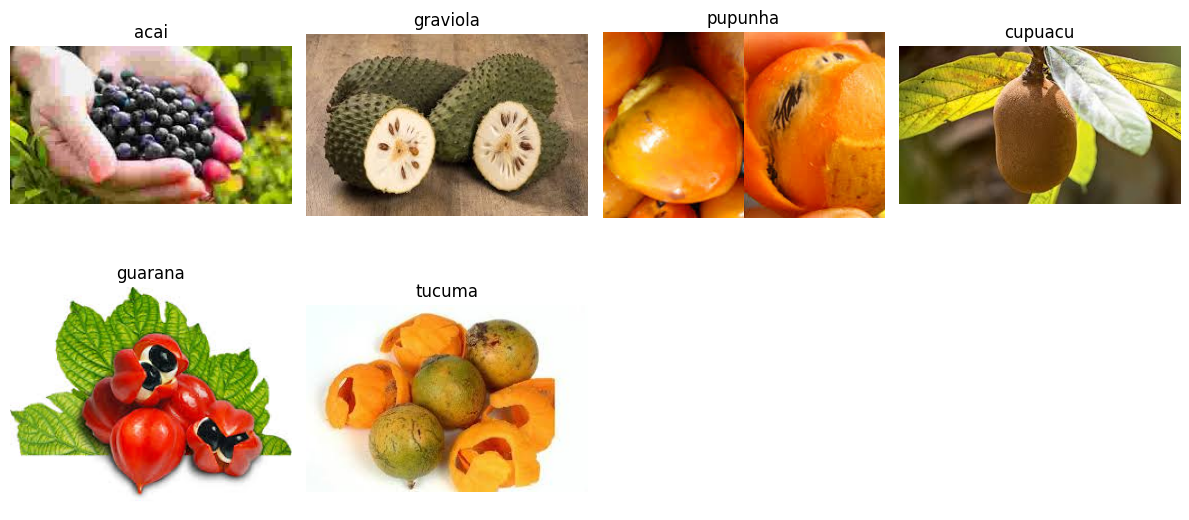

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Ensure train_dir is correctly set (re-evaluation in case of inconsistent kernel state)
train_dir = os.path.join(dataset_root, 'train')

# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image from each class
images = []
titles = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    images.append(Image.open(img_path))
    titles.append(cls)

# Plot in grid (2 rows)
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images)//2)+1, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### 1.2 - Check for Corrupted Images

In [10]:
corrupted_images = []

for class_name in classes: # Changed 'class_dirs' to 'classes'
    class_path = os.path.join(train_dir, class_name)
    for fname in os.listdir(class_path):
        image_path = os.path.join(class_path, fname)
        try:
            with Image.open(image_path) as img:
                img.verify()          # verify does NOT decode—must re-open to fully check
            with Image.open(image_path) as img:
                img.load()
        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


---
## Task 2: Loading and Preprocessing Image Data

In [12]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalize layer
rescale = tf.keras.layers.Rescaling(1./255)

# Train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


---
## Task 3: Build the CNN Architecture

In [13]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


---
## Task 4: Compile and Train the Model

### 4.1 - Compile

In [15]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2 - Define Callbacks & train

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1858 - loss: 1.9329 

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.1667 - loss: 2.0066 - val_accuracy: 0.0000e+00 - val_loss: 1.8677
Epoch 2/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.1562 - loss: 1.7249

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.2361 - loss: 1.7188 - val_accuracy: 0.5000 - val_loss: 1.6664
Epoch 3/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2500 - loss: 1.6540

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2917 - loss: 1.6146 - val_accuracy: 0.5556 - val_loss: 1.5551
Epoch 4/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2812 - loss: 1.5410

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4306 - loss: 1.4193 - val_accuracy: 0.7222 - val_loss: 1.3586
Epoch 5/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6562 - loss: 1.1475

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6667 - loss: 1.1373 - val_accuracy: 0.6111 - val_loss: 0.9819
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7222 - loss: 0.9334 - val_accuracy: 0.3889 - val_loss: 1.3749
Epoch 7/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7500 - loss: 0.6988

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6944 - loss: 0.8518 - val_accuracy: 0.6667 - val_loss: 0.8254
Epoch 8/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8438 - loss: 0.5234

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7778 - loss: 0.6391 - val_accuracy: 0.9444 - val_loss: 0.4914
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8750 - loss: 0.4758 - val_accuracy: 0.8333 - val_loss: 0.6117
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9722 - loss: 0.2536 - val_accuracy: 0.6111 - val_loss: 1.1428
Epoch 11/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9375 - loss: 0.3449

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9306 - loss: 0.3017 - val_accuracy: 0.9444 - val_loss: 0.3253
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9722 - loss: 0.1417 - val_accuracy: 0.8333 - val_loss: 0.4745
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.1100 - val_accuracy: 0.7778 - val_loss: 0.6928
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0616 - val_accuracy: 0.7778 - val_loss: 0.4769
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0355 - val_accuracy: 0.8889 - val_loss: 0.3503
Epoch 16/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0344

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.0293 - val_accuracy: 0.8889 - val_loss: 0.3249
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0248 - val_accuracy: 0.8889 - val_loss: 0.3367
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.8333 - val_loss: 0.4097
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.7778 - val_loss: 0.5127
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.7778 - val_loss: 0.5693
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 0.8333 - val_loss: 0.4928
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.8889 - val_loss: 0.4251
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.8889 - val_loss: 0.40

### 5 - Evaluate


In [18]:
test_dir = os.path.join(dataset_root, 'test')

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step - accuracy: 0.6333 - loss: 1.0158
Test Accuracy: 0.6333333253860474


### Task 6: Save and Load the Model

In [19]:

# Save
model.save("final_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

# Re-evaluate
loaded_model.evaluate(test_ds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6333 - loss: 1.0158


[1.0157541036605835, 0.6333333253860474]

##Task 7: Predictions and Classification Report

In [20]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
    graviola       0.50      0.60      0.55         5
     pupunha       0.71      1.00      0.83         5
     cupuacu       0.62      1.00      0.77         5
     guarana       0.00      0.00      0.00         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.63        30
   macro avg       0.52      0.63      0.57        30
weighted avg       0.52      0.63      0.57        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


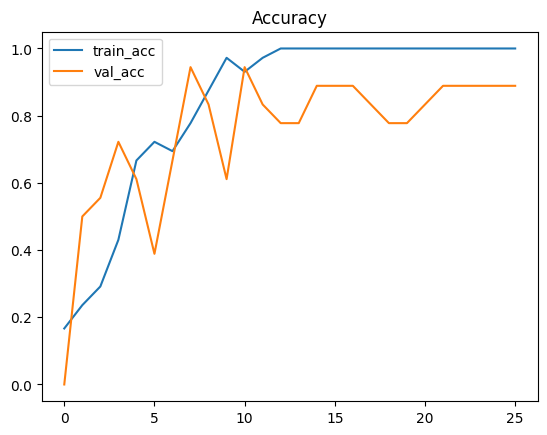

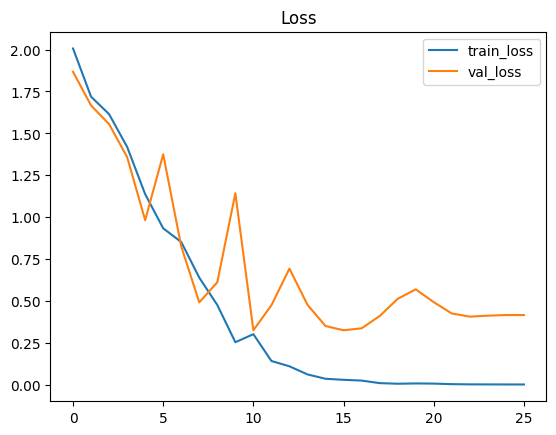

In [21]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()